# **Projeto: Previsão de Intenção de Compra de Clientes em Loja Web**

**Descrição do Projeto**

Neste projeto, nosso objetivo é criar um sistema inteligente para antecipar a intenção de compra dos clientes em um site de e-commerce. Imagine poder prever quais clientes têm maior probabilidade de realizar compras online, com base em suas características e comportamentos passados. Essa capacidade de prever a intenção de compra não só aprimorará a experiência do cliente, mas também permitirá que a empresa direcione seus esforços de marketing de forma mais eficaz.

**Objetivo**

Queremos desenvolver um modelo preditivo capaz de analisar os padrões de comportamento dos clientes e identificar sinais que indicam a propensão deles para realizar compras no site da empresa. Para isso, vamos usar uma base de dados que contém informações detalhadas sobre os clientes, incluindo:

Dados demográficos (idade, renda, etc.)

Informações sobre compras anteriores



# Base de dados:

Year_Birth: Ano de nascimento do cliente.

Education: Nível de escolaridade do cliente.

Marital_Status: Estado civil do cliente.

Income: Renda anual da família do cliente.

Kidhome: Número de crianças na casa do cliente.

Recency: Número de dias desde a última compra do cliente.

Complain: 1 se o cliente reclamou nos últimos 2 anos, 0 caso contrário.

MntWines: Valor gasto em vinhos nos últimos 2 anos.

MntFruits: Valor gasto em frutas nos últimos 2 anos.

MntMeatProducts: Valor gasto em carnes nos últimos 2 anos.

MntFishProducts: Valor gasto em peixes nos últimos 2 anos.

MntSweetProducts: Valor gasto em doces nos últimos 2 anos.

MntGoldProds: Valor gasto em produtos de ouro nos últimos 2 anos.

NumDealsPurchases: Número de compras feitas com desconto

NumStorePurchases: Número de compras feitas diretamente nas lojas.

NumWebVisitsMonth: Número de visitas ao site da empresa no último mês.






**WebPurchases: Se foram feitas compras pelo site da empresa.**

# Importando bibliotecas

In [175]:
# Bibliotecas para arquivo

import os

# Bibliotecas para dados

import pandas as pd
import numpy as np

# Biblioteca para visualização de dados

import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

# Bibliotecas para Pre processamento

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import  OneHotEncoder
from sklearn.preprocessing import StandardScaler

# Bibliotecas para ML

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Bibioltecas para verificar resultados

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.metrics import roc_curve, roc_auc_score

In [176]:
# Padronizacao visual dos graficos

COLOR_PALETTE = {
    "year": "#2D6A4F",
    "income": "#1D4ED8",
    "meat": "#C2410C",
    "neutral": "#6B7280"
}

def aplicar_estilo(fig, titulo, subtitulo=None, x_title=None, y_title=None):
    title_text = titulo
    if subtitulo:
        title_text += f"<br><sup>{subtitulo}</sup>"

    fig.update_layout(
        template="simple_white",
        title=dict(text=title_text, x=0.01, xanchor="left"),
        font=dict(family="DejaVu Sans", size=13, color="#1F2937"),
        plot_bgcolor="#FAFAFA",
        paper_bgcolor="white",
        hoverlabel=dict(bgcolor="white", font_size=12),
        margin=dict(t=80, r=30, b=55, l=55)
    )

    fig.update_xaxes(
        title_text=x_title,
        showgrid=True,
        gridcolor="#E5E7EB",
        zeroline=False
    )
    fig.update_yaxes(
        title_text=y_title,
        showgrid=True,
        gridcolor="#E5E7EB",
        zeroline=False
    )

    return fig



# ETAPA 1:

**Preparação dos Dados**

**Exploração e Limpeza:** Analisar e limpar os dados para garantir que estejam prontos para a modelagem.

**Análise:** Construa uma storytelling com gráficos, analisando e retirando insights das informações.

 - Definindo DF

In [ ]:
# Definido caminho

path = '.\\marketing_campaign.csv'

# Verificando se o caminho existe

if os.path.exists(path):
    print("Caminho encontrado")

else:
    print("Caminho não foi encontrado")

# Definindo df

df = pd.read_csv(path, delimiter=';')

df

O arquivo foi encontrado!!! 


,Year_Birth,Education,Marital_Status,Income,Kidhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumStorePurchases,NumWebVisitsMonth,Complain,WebPurchases
0,1957,Graduation,Single,58138.0,0,58,635,88,546,172,88,88,4,7,0,1
1,1954,Graduation,Single,46344.0,1,38,11,1,6,2,1,6,2,5,0,0
2,1965,Graduation,Together,71613.0,0,26,426,49,127,111,21,42,10,4,0,1
3,1984,Graduation,Together,26646.0,1,26,11,4,20,10,3,5,4,6,0,0
4,1981,PhD,Married,58293.0,1,94,173,43,118,46,27,15,6,5,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,1967,Graduation,Married,61223.0,0,46,709,43,182,42,118,247,4,5,0,1
2236,1946,PhD,Together,64014.0,2,56,406,0,30,0,0,8,5,7,0,1
2237,1981,Graduation,Divorced,56981.0,0,91,908,48,217,32,12,24,13,6,0,0
2238,1956,Master,Together,69245.0,0,8,428,30,214,80,30,61,10,3,0,1


- Verificação inicial do df

In [178]:
# Verificando tipos e se há valores nulos no df

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year_Birth         2240 non-null   int64  
 1   Education          2240 non-null   object 
 2   Marital_Status     2240 non-null   object 
 3   Income             2216 non-null   float64
 4   Kidhome            2240 non-null   int64  
 5   Recency            2240 non-null   int64  
 6   MntWines           2240 non-null   int64  
 7   MntFruits          2240 non-null   int64  
 8   MntMeatProducts    2240 non-null   int64  
 9   MntFishProducts    2240 non-null   int64  
 10  MntSweetProducts   2240 non-null   int64  
 11  MntGoldProds       2240 non-null   int64  
 12  NumStorePurchases  2240 non-null   int64  
 13  NumWebVisitsMonth  2240 non-null   int64  
 14  Complain           2240 non-null   int64  
 15  WebPurchases       2240 non-null   int64  
dtypes: float64(1), int64(13)

Obs: Após a análise inicial foi possível ver que existem duas colunas que são objetos, logo, precisaremos transformá-las em números, e também, foi possível ver que a coluna Income possui 24 valores nulos, logo, o tratamento se faz necessário.

- Verificando valores únicos

In [179]:
# Verificando os valores únicos das colunas que são strings

print(df['Education'].value_counts())

print("\n")

print(df['Marital_Status'].value_counts())



Education
Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: count, dtype: int64


Marital_Status
Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64


Obs: Após a análise foi possível observar que exitem valores incoerentes na coluna Marital_Status, logo, precisamos remove-los.

- Removendo valores incoerentes da coluna Marital_Status

In [180]:
# Substituição "Alone" para "Single"

df['Marital_Status'] = df["Marital_Status"].replace('Alone', 'Single')

# Removendo valores "Absurd" e "YOLO"

df = df[~df['Marital_Status'].isin(['Absurd', 'YOLO'])]

Obs: Resolvi substituir "Alone" por "Single" visto que pode ser um erro de entendimento, logo a substituição faz sentido, e resolvi remover os valores "Absurd" e "YOLO" por serem valores que não remetem a nada e não fazem muito sentido...

- Verificando se deu certo

In [181]:
# Verificando resultado

print(df['Marital_Status'].value_counts())

Marital_Status
Married     864
Together    580
Single      483
Divorced    232
Widow        77
Name: count, dtype: int64


- Limpeza


In [182]:
# Removendo as linhas com valores nulos

try:
    df = df.dropna()
except:
    print("Os valores nulos já foram removidos")

# Verificando se funcionou 

print(df.isnull().sum())

Year_Birth           0
Education            0
Marital_Status       0
Income               0
Kidhome              0
Recency              0
MntWines             0
MntFruits            0
MntMeatProducts      0
MntFishProducts      0
MntSweetProducts     0
MntGoldProds         0
NumStorePurchases    0
NumWebVisitsMonth    0
Complain             0
WebPurchases         0
dtype: int64


Obs: Como são apenas 24 valores nulos, um número pequeno em comparação a quantidade de dados contidos no df, vou apenas remover as linhas que possuem valores nulos.

- Verificando se há outliers

In [183]:
# Describe para a entender a distribuição das variaveis

df.describe()

,Year_Birth,Income,Kidhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumStorePurchases,NumWebVisitsMonth,Complain,WebPurchases
count,2212.000000,2212.000000,2212.000000,2212.000000,2212.000000,2212.000000,2212.000000,2212.000000,2212.000000,2212.000000,2212.000000,2212.000000,2212.000000,2212.000000
mean,1968.811031,52232.510850,0.442586,49.050633,305.030741,26.324593,166.970163,37.516275,27.047468,43.822333,5.800181,5.320072,0.009494,0.504069
std,11.982065,25187.455359,0.537052,28.940794,337.611255,39.781794,224.344950,54.558673,41.092454,51.623472,3.253616,2.423445,0.096994,0.500096
min,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1959.000000,35233.500000,0.000000,24.000000,23.750000,1.750000,16.000000,3.000000,1.000000,9.000000,3.000000,3.000000,0.000000,0.000000
50%,1970.000000,51381.500000,0.000000,49.000000,173.500000,8.000000,68.000000,12.000000,8.000000,24.000000,5.000000,6.000000,0.000000,1.000000
75%,1977.000000,68522.000000,1.000000,74.000000,505.500000,33.000000,232.250000,50.000000,33.000000,56.000000,8.000000,7.000000,0.000000,1.000000
max,1996.000000,666666.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,262.000000,321.000000,13.000000,20.000000,1.000000,1.000000


Obs: Após uma análise inicial, pode-se ver que há dados errôneos em algumas colunas, sendo elas: 

- Year_Birth - Mostrou um valor de 1893, oq seria impossível já que a pessoa teria mais de cem anos, indicando um erro

- Income - Que tem seus 75% em 68522, e seu maior valor em 666666, o que teoricamente pode até ser possível, mas é improvável, logo faremos uma analise mais aprofundada

- MntMeatProducts - Que tem seus 75% em 232.25 e seu valor máximo em 1725, o que por sua vez pode até ser possível, visto que talvez fosse um restaurante ou algo do tipo comprando a carne, mas ainda assim é improvavel, logo, também faremos uma analise para entendermos melhor o que está acontecendo.

A princípio, essas são as variáveis que mais demonstram possíveis problemas, a seguir farei uma análise em cada uma delas para então decidir como iremos prosseguir


Year_Birth

In [184]:
# Analise visual de Year_Birth (Boxplot)

df_year = df.assign(Idade=pd.Timestamp.today().year - df["Year_Birth"])

fig = px.box(
    df_year,
    x="Year_Birth",
    points="outliers",
    color_discrete_sequence=[COLOR_PALETTE["year"]],
    custom_data=["Idade"]
)

aplicar_estilo(
    fig,
    "Ano de nascimento dos clientes",
    "Boxplot inicial para localizar registros fora do padrao",
    "Ano de nascimento",
    None
)
fig.update_traces(
    jitter=0.18,
    pointpos=0,
    marker=dict(size=7, opacity=0.65, line=dict(width=1, color="white")),
    hovertemplate="Ano de nascimento: %{x}<br>Idade estimada: %{customdata[0]:.0f} anos<extra></extra>"
)
fig.show()

# Removendo outliers
cond = df["Year_Birth"] < 1930
df = df[~cond]

# Verificando resultados
df_year = df.assign(Idade=pd.Timestamp.today().year - df["Year_Birth"])

fig = px.histogram(
    df_year,
    x="Year_Birth",
    nbins=18,
    color_discrete_sequence=[COLOR_PALETTE["year"]]
)

aplicar_estilo(
    fig,
    "Distribuicao de clientes por ano de nascimento",
    f"Base ajustada com {df_year.shape[0]} clientes",
    "Ano de nascimento",
    "Quantidade de clientes"
)
fig.add_vline(
    x=df_year["Year_Birth"].median(),
    line_dash="dash",
    line_color=COLOR_PALETTE["neutral"],
    annotation_text="Mediana",
    annotation_position="top"
)
fig.update_traces(hovertemplate="Ano de nascimento: %{x}<br>Clientes: %{y}<extra></extra>")
fig.show()



Obs: Após a análise do gráfico foi possível ver que haviam 3 outliers (Eram datas que a pessoa teria que ter mais de 120 anos, o que por sua vez seria muito improvável, e não seria de ajuda para o modelo) em Year_Birth, uma quantidade pequena de valores, logo, decidi remove-los.

Income

In [185]:
# Analise visual de Income (BoxPlot)

fig = px.box(
    df,
    x="Income",
    points="outliers",
    color_discrete_sequence=[COLOR_PALETTE["income"]]
)

aplicar_estilo(
    fig,
    "Renda anual dos clientes",
    "Boxplot para validar dispersao e outliers relevantes",
    "Renda anual (R$)",
    None
)
fig.update_traces(
    jitter=0.18,
    pointpos=0,
    marker=dict(size=7, opacity=0.65, line=dict(width=1, color="white")),
    hovertemplate="Renda anual: R$ %{x:,.0f}<extra></extra>"
)
fig.update_xaxes(tickprefix="R$ ", separatethousands=True)
fig.show()

# Removendo outlier muito acima do restante da base
cond = df["Income"] > 200000
df = df[~cond]

# Verificando remocao com um histograma
fig = px.histogram(
    df,
    x="Income",
    nbins=20,
    color_discrete_sequence=[COLOR_PALETTE["income"]]
)

aplicar_estilo(
    fig,
    "Distribuicao da renda apos o tratamento",
    f"Mediana de renda em R$ {df['Income'].median():,.0f}",
    "Renda anual (R$)",
    "Quantidade de clientes"
)
fig.add_vline(
    x=df["Income"].median(),
    line_dash="dash",
    line_color=COLOR_PALETTE["neutral"],
    annotation_text="Mediana",
    annotation_position="top"
)
fig.update_xaxes(tickprefix="R$ ", separatethousands=True)
fig.update_traces(hovertemplate="Faixa de renda: R$ %{x:,.0f}<br>Clientes: %{y}<extra></extra>")
fig.show()



Obs: Após a análise, foi possível ver apenas 1 outlier (possuia uma renda anual de 666.666k e apesar de ser possível, é extremamente improvável, principalmente por causa do números, que são iguais, possivelmente indicando um erro de digitação, logo acredito que não seria de grande ajuda para o modelo.), por haver apenas um valor, decidi remover esta linha.

MntMeatProducts

In [186]:
# Analise visual de MntMeatProducts

fig = px.box(
    df,
    y="MntMeatProducts",
    points="outliers",
    color_discrete_sequence=[COLOR_PALETTE["meat"]],
    hover_data={
        "Income": ":,.0f",
        "Kidhome": True,
        "NumStorePurchases": True
    },
    labels={
        "MntMeatProducts": "Gasto com carnes nos ultimos 2 anos (R$)",
        "Income": "Renda anual (R$)",
        "Kidhome": "Criancas em casa",
        "NumStorePurchases": "Compras em loja"
    }
)

aplicar_estilo(
    fig,
    "Distribuicao do gasto com carnes",
    "Boxplot com renda anual exibida no hover dos pontos extremos",
    None,
    "Gasto com carnes (R$)"
)
fig.add_hline(
    y=df["MntMeatProducts"].median(),
    line_dash="dot",
    line_color="#9A3412",
    annotation_text="Mediana do gasto",
    annotation_position="top left"
)
fig.update_yaxes(tickprefix="R$ ", separatethousands=True)
fig.update_traces(
    jitter=0.18,
    pointpos=0,
    marker=dict(size=7, opacity=0.65, line=dict(width=1, color="white")),
    hovertemplate="Gasto com carnes: R$ %{y:,.0f}<br>Renda anual: R$ %{customdata[0]:,.0f}<br>Criancas em casa: %{customdata[1]}<br>Compras em loja: %{customdata[2]}<extra></extra>"
)
fig.show()

# Removendo apenas casos com gasto muito alto em carne e renda relativamente baixa
cond = (df["MntMeatProducts"] > 1000) & (df["Income"] < 50000)
df = df[~cond]

# Verificando se a remocao funcionou
fig = px.histogram(
    df,
    x="MntMeatProducts",
    nbins=20,
    color_discrete_sequence=[COLOR_PALETTE["meat"]]
)

aplicar_estilo(
    fig,
    "Distribuicao do gasto com carnes apos o tratamento",
    f"Mediana de gasto em R$ {df['MntMeatProducts'].median():,.0f}",
    "Gasto com carnes (R$)",
    "Quantidade de clientes"
)
fig.add_vline(
    x=df["MntMeatProducts"].median(),
    line_dash="dash",
    line_color=COLOR_PALETTE["neutral"],
    annotation_text="Mediana",
    annotation_position="top"
)
fig.update_xaxes(tickprefix="R$ ", separatethousands=True)
fig.update_traces(hovertemplate="Faixa de gasto: R$ %{x:,.0f}<br>Clientes: %{y}<extra></extra>")
fig.show()

Obs: Após a análise encontramos novamente 1 outlier (Isso aconteceu pois apesar de ter uma quantidade maior de valores que saem dos quadrantes no boxplot, eles em sua maioria faziam sentido, visto que podia ser o caso por exemplo de um restaurante que compra na loja, uma churrascaria... Qualquer estabelecimento que precisava gastar muito em carnes pois iria vender, todavia, se é estabelecimento que está comprando, espera-se uma renda anual razoável, para ao menos conseguir ter dinheiro para continuar reabastecendo a loja, logo, removi a linha que o valor gasto em carne era grande demais quando comparado com a renda anual. ), e novamente, decidi remove-lo.

Verificando resultados após a remoção dos outliers.

In [187]:
# Verificando resultado com describre

df.describe()

,Year_Birth,Income,Kidhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumStorePurchases,NumWebVisitsMonth,Complain,WebPurchases
count,2207.000000,2207.000000,2207.000000,2207.000000,2207.000000,2207.000000,2207.000000,2207.000000,2207.000000,2207.000000,2207.000000,2207.000000,2207.000000,2207.000000
mean,1968.899864,51965.947893,0.442229,49.060716,305.364749,26.309470,166.298142,37.543725,27.077028,43.801994,5.808337,5.324422,0.009062,0.504758
std,11.698247,21515.833369,0.537102,28.941698,337.621174,39.737133,221.900309,54.585230,41.117024,51.517597,3.252165,2.422480,0.094784,0.500091
min,1940.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1959.000000,35221.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,1.000000,9.000000,3.000000,3.000000,0.000000,0.000000
50%,1970.000000,51373.000000,0.000000,49.000000,174.000000,8.000000,68.000000,12.000000,8.000000,24.000000,5.000000,6.000000,0.000000,1.000000
75%,1977.000000,68487.000000,1.000000,74.000000,506.000000,33.000000,232.000000,50.000000,33.000000,56.000000,8.000000,7.000000,0.000000,1.000000
max,1996.000000,162397.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,262.000000,321.000000,13.000000,20.000000,1.000000,1.000000


Obs: Agora sim os valores fazem bem mais sentido, e tivemos uma perda de apenas 29 linhas em comparação ao DF original.

- EDA

Já fizemos uma pequena exploração enquanto verificávamos os possíveis outliers, agora, essa EDA terá como foco visualizar como as variáveis se relacionam com a variável alvo. E para termos um norte, farei agora a matriz para ver a correlação entre a variáveis.

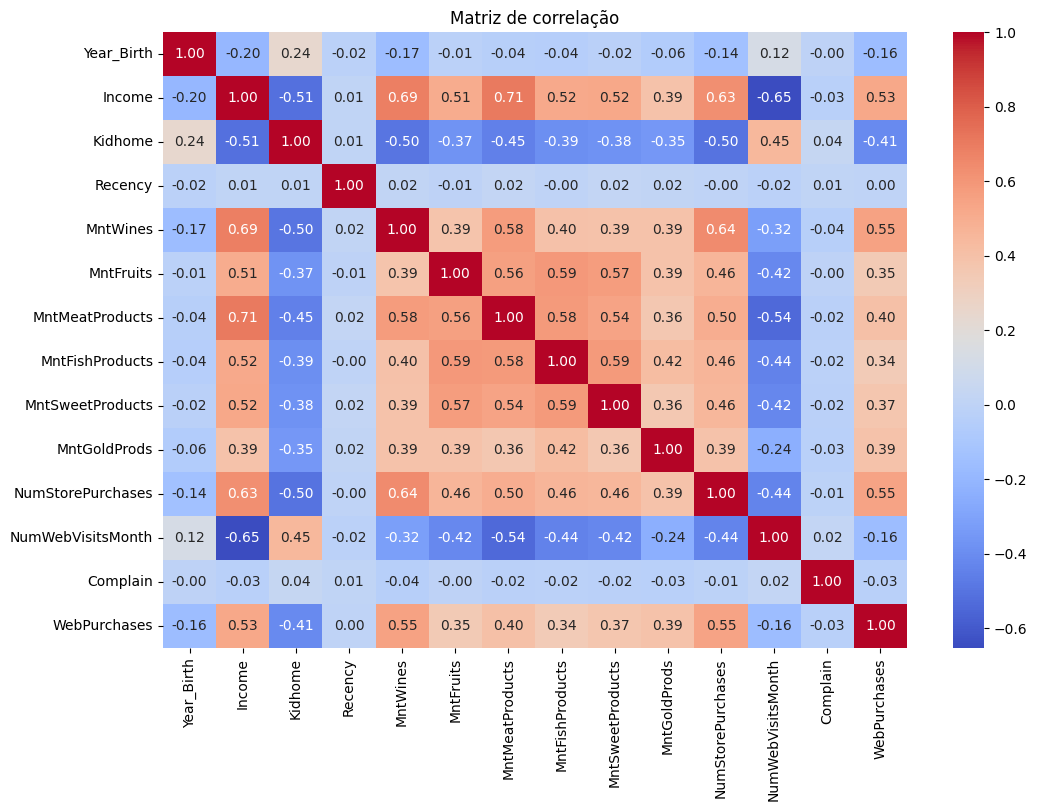

In [188]:
# Criando gráfico para verificar a correlação das variáveis

matriz_corr = df.select_dtypes(include="number").corr()

plt.figure(figsize=(12,8))
sns.heatmap(matriz_corr, annot=True, cmap="coolwarm", fmt=".2f", annot_kws={"size":10})
plt.title("Matriz de correlação")
plt.show()


Obs: Podemos observar aqui algumas correlações interessantes que trazem algumas hipóteses para entender e explicar a base. Com base nas informações acima faremos 3 gráficos iniciais, Year_Birth x WebPurchase, Income x Web_Purchase e Gasto por categoria x WebPurchase.

- Income x WebPurchase

In [189]:
# Gráfico

fig = px.box(
    df,
    x="WebPurchases",
    y="Income",
    color="WebPurchases",
    color_discrete_map={0: COLOR_PALETTE["neutral"], 1: COLOR_PALETTE["income"]},
    labels={"WebPurchases": "Compra no site", "Income": "Renda anual (R$)"}
)

aplicar_estilo(
    fig,
    "Renda anual por comportamento de compra online",
    "Clientes que compram no site tendem a ter maior renda",
    "Compra no site (0 = Não | 1 = Sim)",
    "Renda anual (R$)"
)
fig.update_xaxes(tickvals=[0, 1], ticktext=["Não compra", "Compra"])
fig.update_yaxes(tickprefix="R$ ", separatethousands=True)
fig.show()

Insights: Clientes que compram pelo site tendem a ter renda significativamente maior, embora haja exceções com renda elevada que não compram online.

- Year_Birth vs WebPurchases

In [190]:
# Gráfioc

fig = px.box(
    df,
    x="WebPurchases",
    y="Year_Birth",
    color="WebPurchases",
    color_discrete_map={0: COLOR_PALETTE["neutral"], 1: COLOR_PALETTE["year"]},
    labels={"WebPurchases": "Compra no site", "Year_Birth": "Ano de nascimento"}
)

aplicar_estilo(
    fig,
    "Ano de nascimento por comportamento de compra online",
    "Clientes mais velhos tendem a comprar mais pelo site",
    "Compra no site (0 = Não | 1 = Sim)",
    "Ano de nascimento"
)
fig.update_xaxes(tickvals=[0, 1], ticktext=["Não compra", "Compra"])
fig.show()

Insights: O gráfico revela uma leve tendência de clientes com ano de nascimento menor (mais velhos) a realizarem compras pelo site. No entanto, a diferença entre as medianas dos dois grupos é pequena e as distribuições se sobrepõem consideravelmente, indicando que a idade por si só não é um fator determinante para o comportamento de compra online.

- Gasto por categoria vs WebPurchases

In [191]:
# Gráfico

mnt_cols = ['MntWines', 'MntFruits', 'MntMeatProducts',
            'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']

df_mnt = df.groupby('WebPurchases')[mnt_cols].mean().reset_index()
df_melt = df_mnt.melt(id_vars='WebPurchases', var_name='Categoria', value_name='Media')
df_melt['WebPurchases'] = df_melt['WebPurchases'].map({0: "Não compra", 1: "Compra"})

fig = px.bar(
    df_melt,
    x="Categoria",
    y="Media",
    color="WebPurchases",
    barmode="group",
    color_discrete_map={"Não compra": COLOR_PALETTE["neutral"], "Compra": COLOR_PALETTE["income"]},
    labels={"Media": "Gasto médio (R$)", "Categoria": "Categoria de produto"}
)

aplicar_estilo(
    fig,
    "Gasto medio por categoria de produto",
    "Comparativo entre clientes que compram ou nao pelo site",
    "Categoria",
    "Gasto medio (R$)"
)
fig.update_yaxes(tickprefix="R$ ", separatethousands=True)
fig.update_xaxes(tickvals=mnt_cols,
                 ticktext=["Vinhos", "Frutas", "Carnes", "Peixes", "Doces", "Ouro"])
fig.show()

Insights: O gráfico evidencia que clientes que realizam compras pelo site apresentam gasto médio superior em todas as categorias de produto, com destaque para vinhos e carnes, onde a diferença é mais expressiva.

- Kidhome x WebPurchases

In [192]:
# Gráfico

df_kids = df.groupby(['Kidhome', 'WebPurchases']).size().reset_index(name='Count')
df_kids['WebPurchases'] = df_kids['WebPurchases'].map({0: "Não compra", 1: "Compra"})

fig = px.bar(
    df_kids,
    x="Kidhome",
    y="Count",
    color="WebPurchases",
    barmode="group",
    color_discrete_map={"Não compra": COLOR_PALETTE["neutral"], "Compra": COLOR_PALETTE["year"]},
    labels={"Kidhome": "Crianças em casa", "Count": "Quantidade de clientes"}
)

aplicar_estilo(
    fig,
    "Comportamento de compra online por número de crianças em casa",
    "Clientes sem filhos tendem a comprar mais pelo site",
    "Crianças em casa",
    "Quantidade de clientes"
)
fig.show()

Insights: O gráfico mostra uma relação clara entre presença de crianças em casa e comportamento de compra online. Clientes sem filhos compram pelo site muito mais que os que têm filhos, e essa tendência se acentua conforme o número de crianças aumenta.

- Storytelling, Entendendo os dados:

Análise: Olhando os dados, dá pra traçar um perfil bastante claro de quem compra pelo site: são clientes levemente mais velhos, com renda bem maior do que quem prefere a loja física, e na maioria sem filhos em casa. Além disso, quem compra online gasta significativamente mais em todas as categorias, especialmente em vinhos e carnes.

Hipóteses: Com base nos padrões observados, levantei algumas hipóteses para explicar esse comportamento:

-> O canal online pode oferecer maior variedade de produtos e opções mais especializadas, atraindo um perfil de cliente com maior poder aquisitivo e disposição para gastar mais.

-> Clientes sem filhos podem ter mais disponibilidade financeira e de tempo para explorar o canal online, enquanto famílias com crianças tendem a priorizar compras presenciais e mais práticas.

-> O maior gasto médio online pode refletir compras em maior volume ou frequência, e não necessariamente produtos mais caros — hipótese que não pode ser confirmada apenas com os dados disponíveis.

# ETAPA 2:
**Pré-processamento**

**Análise Correlação:** Verifique a correlação entre as váriaveis e análise se há espaço para retirar váriaveis que não te parecem importantes.

**Codificação de Variáveis Categóricas:** Transformar variáveis categóricas em um formato que os modelos de machine learning possam interpretar.


**Separe a base em Y, X e Treino e teste:**: Faça a separação da base.

**Realize a padronização dos dados**: Padronize os dados para garantir eficiência no modelo e eficácia.








- Análise Correlação (Para remoção de variáveis)

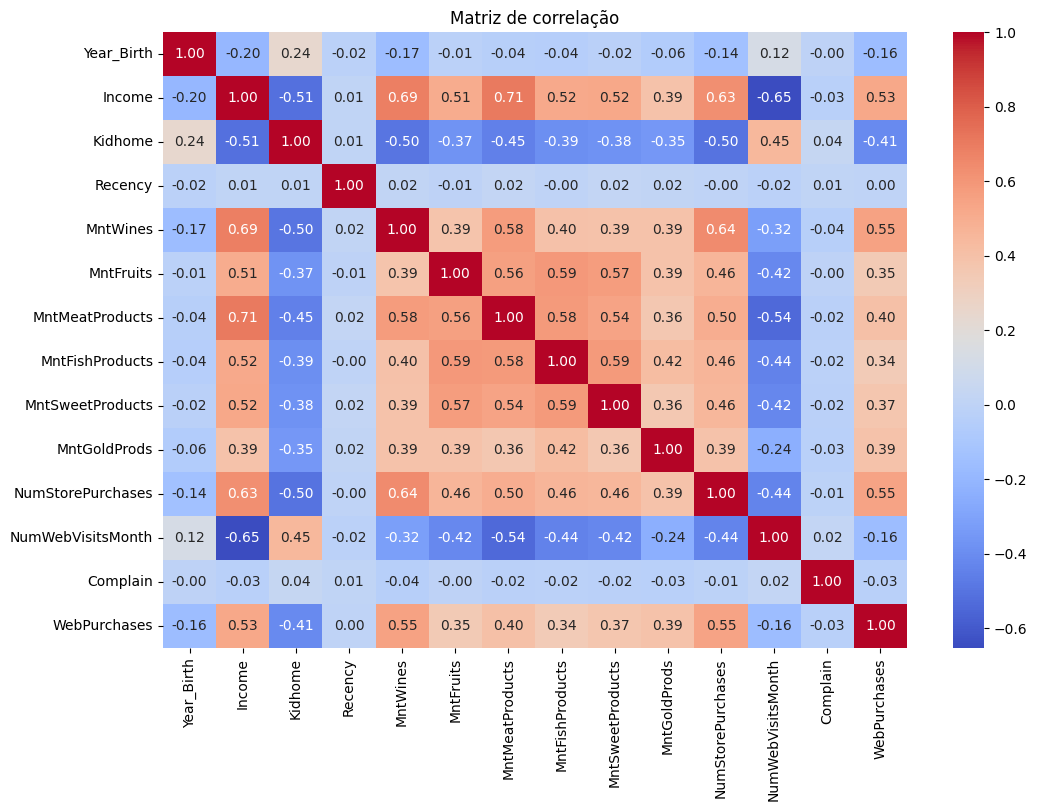

In [193]:
# Criando gráfico para verificar a correlação das variáveis

matriz_corr = df.select_dtypes(include="number").corr()

plt.figure(figsize=(12,8))
sns.heatmap(matriz_corr, annot=True, cmap="coolwarm", fmt=".2f", annot_kws={"size":10})
plt.title("Matriz de correlação")
plt.show()

Obs: Com base na análise feita, decidi remover as categorias Recency e complain, que tem baixa correlação com a variável target e baixa correlação com qualquer outra variável, e por isso, não será de grande ajuda para o entendimento do modelo.

- Remoção da coluna "Recency"

In [194]:
# Removendo a coluna

df = df.drop(columns=['Recency', 'Complain'])

Verificando resultado

In [195]:
df

,Year_Birth,Education,Marital_Status,Income,Kidhome,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumStorePurchases,NumWebVisitsMonth,WebPurchases
0,1957,Graduation,Single,58138.0,0,635,88,546,172,88,88,4,7,1
1,1954,Graduation,Single,46344.0,1,11,1,6,2,1,6,2,5,0
2,1965,Graduation,Together,71613.0,0,426,49,127,111,21,42,10,4,1
3,1984,Graduation,Together,26646.0,1,11,4,20,10,3,5,4,6,0
4,1981,PhD,Married,58293.0,1,173,43,118,46,27,15,6,5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,1967,Graduation,Married,61223.0,0,709,43,182,42,118,247,4,5,1
2236,1946,PhD,Together,64014.0,2,406,0,30,0,0,8,5,7,1
2237,1981,Graduation,Divorced,56981.0,0,908,48,217,32,12,24,13,6,0
2238,1956,Master,Together,69245.0,0,428,30,214,80,30,61,10,3,1


- Codificação das variáveis categóricas

In [196]:
# Codificando variáveis com get_dummies

df = pd.get_dummies(df, columns=['Education', 'Marital_Status'], drop_first=True).astype(int)

Obs: Aqui codifiquei as duas variáveis categóricas e utilizei get_dummies, escolhi essa opção pois label encoder só é mais interessante quando já existe uma ordem natural na coluna, e esse não é o caso nessa situação, e sua utilização poderia gerar um viés no modelo, dando importância maior para variáveis que não a possuem.

- Verificando Resultado

In [197]:
df.head()

,Year_Birth,Income,Kidhome,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumStorePurchases,NumWebVisitsMonth,WebPurchases,Education_Basic,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Married,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow
0,1957,58138,0,635,88,546,172,88,88,4,7,1,0,1,0,0,0,1,0,0
1,1954,46344,1,11,1,6,2,1,6,2,5,0,0,1,0,0,0,1,0,0
2,1965,71613,0,426,49,127,111,21,42,10,4,1,0,1,0,0,0,0,1,0
3,1984,26646,1,11,4,20,10,3,5,4,6,0,0,1,0,0,0,0,1,0
4,1981,58293,1,173,43,118,46,27,15,6,5,1,0,0,0,1,1,0,0,0


- Separando em X e y

In [198]:
# Separando X

X = df.drop(columns=['WebPurchases'])

# Separando y

y = df['WebPurchases']

- Separando em treino e teste

In [199]:
# Separando em treino e teste

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state=48)

# Verificando se a separação funcionou

print("X Train: ", X_train.shape)
print("X test: ", X_test.shape)
print("y train: ",y_train.shape)
print("y test", y_test.shape)

X Train:  (1765, 19)
X test:  (442, 19)
y train:  (1765,)
y test (442,)


- Padronização dos dados

In [200]:
# Criando instância do StandardScaler

SS = StandardScaler()

# Padronizando treino

X_train = SS.fit_transform(X_train)

# Padronizando test

X_test = SS.transform(X_test)

# ETAPA 3:

**Modelagem**

Escolha ao menos 2 técnicas de machine learning e rode 2 modelos, afim de identificar qual tem o melhor resultado para essa base. Lembrando que estamos lidando com uma classificação binária.

- Random Forest

In [201]:
# Instanciando o modelo

forest = RandomForestClassifier(random_state=48)

# Treinando o modelo

forest.fit(X_train, y_train)

# Predição

pred_forest = forest.predict(X_test)

- Logistic Regression

In [202]:
# Instanciando o modelo

logistic = LogisticRegression(random_state=48)

# Treinando o modelo

logistic.fit(X_train, y_train)

# Predição

pred_logistic = logistic.predict(X_test)

# ETAPA 4:

**Avaliação**

Avalie os resultados encontrados nos dois modelos e identifique qual te pareceu realizar melhor as previsões.

Utilize além das métricas padrões a matriz de confusão.

- Resultados Random Forest

              precision    recall  f1-score   support

           0       0.90      0.88      0.89       225
           1       0.88      0.89      0.89       217

    accuracy                           0.89       442
   macro avg       0.89      0.89      0.89       442
weighted avg       0.89      0.89      0.89       442



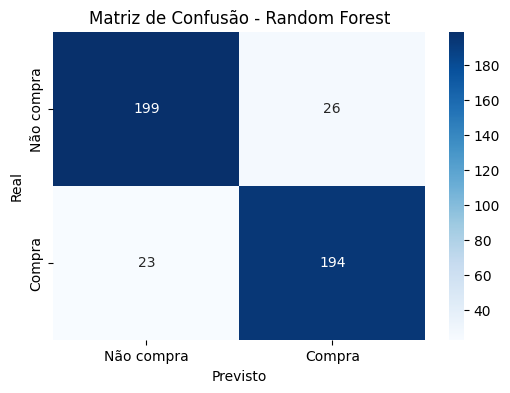

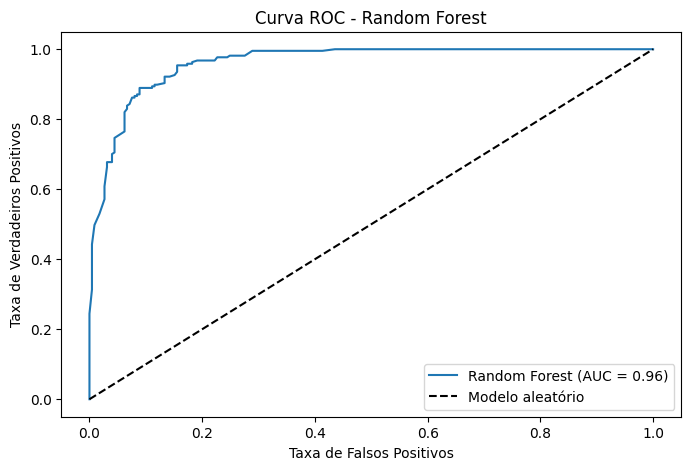

In [203]:
# Verificação com Classification report

report = classification_report(y_test, pred_forest)
print(report)

# Verificação com Confusion Matrix

matrix = confusion_matrix(y_test, pred_forest)

# Gráfico para Matrix

plt.figure(figsize=(6,4))
sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não compra', 'Compra'],
            yticklabels=['Não compra', 'Compra'])
plt.title('Matriz de Confusão - Random Forest')
plt.ylabel('Real')
plt.xlabel('Previsto')
plt.show()

# Gráfico AUC ROC

y_prob_forest = forest.predict_proba(X_test)[:, 1]
fpr_f, tpr_f, _ = roc_curve(y_test, y_prob_forest)
auc_forest = roc_auc_score(y_test, y_prob_forest)

# Gráfico

plt.figure(figsize=(8, 5))
plt.plot(fpr_f, tpr_f, label=f'Random Forest (AUC = {auc_forest:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Modelo aleatório')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC - Random Forest')
plt.legend()
plt.show()

Avaliação: O modelo apresentou um desempenho muito sólido, atingindo 90% de acurácia e AUC de 0.96 na curva ROC, o que indica excelente capacidade de separar as duas classes. A performance foi equilibrada entre as classes, com 199 verdadeiros negativos e 194 verdadeiros positivos. Em relação aos erros, o modelo cometeu 26 falsos positivos e 23 falsos negativos, ou seja, errou levemente mais ao classificar como comprador alguém que não compraria, o que no contexto de campanhas de marketing é o erro menos custoso: é melhor impactar alguém que não ia comprar do que deixar de identificar alguém que ia. É esperado que o desempenho sofra uma leve queda em produção, dado que o Random Forest tende a se ajustar bem aos dados de treino, mas os resultados indicam um modelo robusto e confiável.

- Resultados Logistic Regression

              precision    recall  f1-score   support

           0       0.85      0.85      0.85       225
           1       0.84      0.84      0.84       217

    accuracy                           0.85       442
   macro avg       0.85      0.85      0.85       442
weighted avg       0.85      0.85      0.85       442



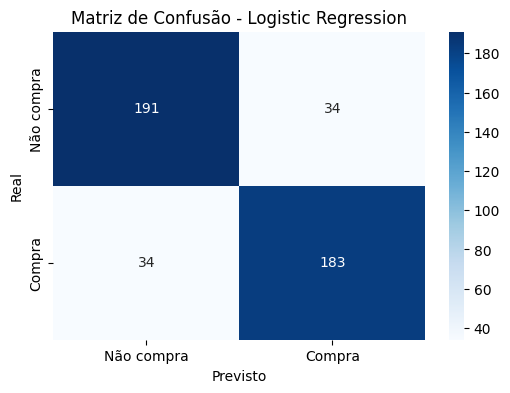

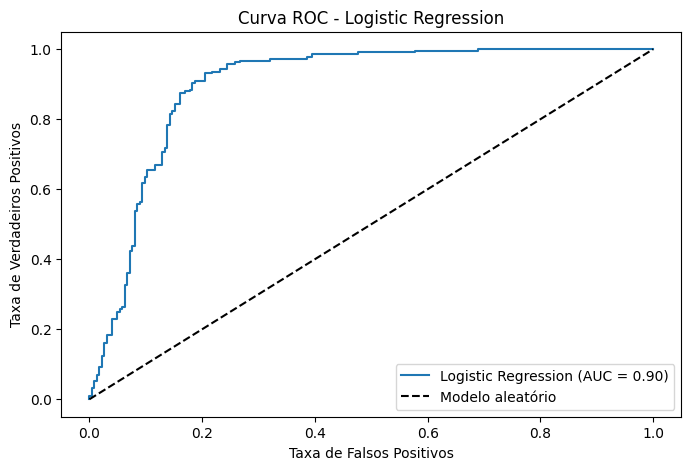

In [204]:
# Verificação com Classification report

report = classification_report(y_test, pred_logistic)
print(report)

# Verificação com Confusion Matrix

matrix = confusion_matrix(y_test, pred_logistic)

# Gráfico para Matrix

plt.figure(figsize=(6,4))
sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não compra', 'Compra'],
            yticklabels=['Não compra', 'Compra'])
plt.title('Matriz de Confusão - Logistic Regression')
plt.ylabel('Real')
plt.xlabel('Previsto')
plt.show()

# Gráfico AUC ROC

y_prob_logistic = logistic.predict_proba(X_test)[:, 1]
fpr_l, tpr_l, _ = roc_curve(y_test, y_prob_logistic)
auc_logistic = roc_auc_score(y_test, y_prob_logistic)

# Gráfico
plt.figure(figsize=(8, 5))
plt.plot(fpr_l, tpr_l, label=f'Logistic Regression (AUC = {auc_logistic:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Modelo aleatório')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC - Logistic Regression')
plt.legend()
plt.show()


Avaliação: O modelo apresentou um desempenho consistente, atingindo 85% de acurácia e AUC de 0.90 na curva ROC. Diferente do Random Forest, ele demonstrou leve vantagem em identificar quem não compra — 191 verdadeiros negativos contra 183 verdadeiros positivos — e um dado curioso: os erros foram perfeitamente simétricos, com 34 falsos positivos e 34 falsos negativos. Apesar de inferior ao Random Forest em todas as métricas, a Regressão Logística tende a generalizar melhor em dados novos, sendo menos suscetível a overfitting. Os resultados são sólidos e indicam um modelo com boa capacidade preditiva, embora testes em dados reais sejam necessários antes de qualquer decisão de uso em produção.

- Qual modelo escolheria e porquê?

Random Forest

Com base nos resultados obtidos, o modelo escolhido para este problema é o Random Forest. Apesar de ambos os modelos terem apresentado bons resultados, o Random Forest se destacou em todas as métricas — 90% de acurácia contra 85% da Regressão Logística, e AUC de 0.96 contra 0.90 — demonstrando maior capacidade preditiva e robustez.

É esperado que, em produção, o modelo sofra uma leve queda de desempenho, já que o Random Forest tende a se ajustar muito bem aos dados de treino. No entanto, os resultados obtidos indicam uma base sólida o suficiente para absorver essa variação e ainda assim manter um desempenho relevante.

Outro fator determinante na escolha foi a capacidade do Random Forest de lidar bem com dados desbalanceados — algo comum em situações reais, onde a proporção entre quem compra e quem não compra no site raramente será tão equilibrada quanto nesta base. A Regressão Logística, apesar de mais estável e menos propensa a overfitting, é um modelo mais sensível a esse tipo de variação.

Por fim, no contexto de campanhas de marketing, identificar corretamente quem tem propensão a comprar é mais valioso do que evitar falsos positivos — e o Random Forest demonstrou exatamente essa capacidade.
